## 1-Functions in Python

In [1]:
# f(x) = x ^ 2
def f(x):
    return x**2

print(f(4))

16


In [2]:
def dfdx(x):
    return 2*x

print(dfdx(3))

6


In [3]:
# apply the function to each element of an array
import numpy as np

x_array = np.array([1,2,3])
print("x: \n", x_array)
print("f(x) = x**2: \n", f(x_array))
print("f'(x) = 2x: \n", dfdx(x_array))

x: 
 [1 2 3]
f(x) = x**2: 
 [1 4 9]
f'(x) = 2x: 
 [2 4 6]


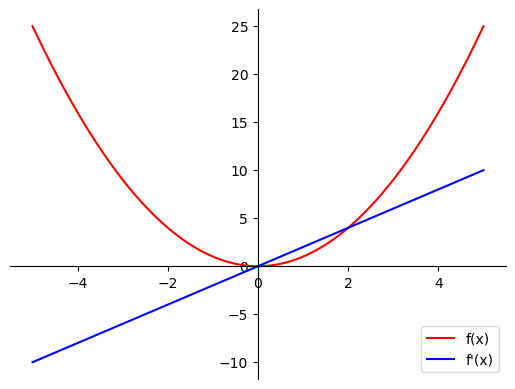

In [4]:
import matplotlib.pyplot as plt

# Output of plotting commands is displayed inline within the Jupyter notebook.
%matplotlib inline

def plot_f1_and_f2(f1, f2=None, x_min=-5, x_max=5, label1="f(x)", label2="f'(x)"):
    x = np.linspace(x_min, x_max,100)

    # Setting the axes at the centre.
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    plt.plot(x, f1(x), 'r', label=label1)
    if not f2 is None:
        # If f2 is an array, it is passed as it is to be plotted as unlinked points.
        # If f2 is a function, f2(x) needs to be passed to plot it.        
        if isinstance(f2, np.ndarray):
            plt.plot(x, f2, 'bo', markersize=3, label=label2,)
        else:
            plt.plot(x, f2(x), 'b', label=label2)
    plt.legend()

    plt.show()
    
plot_f1_and_f2(f, dfdx)

## 2 -Symbolic Differentiation

In [1]:
import math

math.sqrt(18)  # approximate result

4.242640687119285

In [2]:
from sympy import *

sqrt(18)

3*sqrt(2)

In [3]:
# set the number of digits to see the approximated output
N(sqrt(18),8)

4.2426407

In [5]:
# list of symbols
x, y = symbols('x y')
expr = 2 * x**2 - x * y
expr

2*x**2 - x*y

In [6]:
expr_manip = x * (expr + x * y + x**3)
expr_manip

x*(x**3 + 2*x**2)

In [7]:
dfdx_abs = diff(abs(x),x)
dfdx_abs

(re(x)*Derivative(re(x), x) + im(x)*Derivative(im(x), x))*sign(x)/x

In [8]:
dfdx_abs.evalf(subs={x:-2})

-Subs(Derivative(re(x), x), x, -2)

In [9]:
## limitations
## output expressions are too complicated
## and not even possible to evaluate

In [10]:
## automatic differentiation
## MyGrad, Autograd, JAX

## 4 - Introduction to JAX

In [1]:
from jax import grad, vmap
import jax.numpy as jnp

In [2]:
# automatic differentiation
# chain rule

# MyGrad, Autograd, JAX
# Autograd syntax similar to JAX

In [3]:
x_array_jnp = jnp.array([1., 2., 3.])

#print("Type of NumPy array:", type(x_array))
print("Type of JAX NumPy array:", type(x_array_jnp))
# Please ignore the warning message if it appears.

Type of JAX NumPy array: <class 'jaxlib.xla_extension.ArrayImpl'>


In [7]:
import numpy as np
x_array = np.array([1, 2, 3])
x_array_jnp = jnp.array(x_array.astype('float32'))
print("JAX NumPy array:", x_array_jnp)
print("Type of JAX NumPy array:", type(x_array_jnp))

JAX NumPy array: [1. 2. 3.]
Type of JAX NumPy array: <class 'jaxlib.xla_extension.ArrayImpl'>


In [8]:
print(x_array_jnp * 2)
print(x_array_jnp[2])

[2. 4. 6.]
3.0


In [9]:
try:
    x_array_jnp[2] = 4.0
except TypeError as err:
    print(err)

'<class 'jaxlib.xla_extension.ArrayImpl'>' object does not support item assignment. JAX arrays are immutable. Instead of ``x[idx] = y``, use ``x = x.at[idx].set(y)`` or another .at[] method: https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.ndarray.at.html


In [10]:
y_array_jnp = x_array_jnp.at[2].set(4.0)
print(y_array_jnp)

[1. 2. 4.]


In [11]:
print(jnp.log(x_array))
print(jnp.log(x_array_jnp))

[0.        0.6931472 1.0986123]
[0.        0.6931472 1.0986123]


In [ ]:
# automatic differentiation with JAX
